# 📘 Trabalho T2 – Teorema do Limite Central (TLC)

Este trabalho tem como objetivo investigar, por meio de simulações, o comportamento da distribuição das médias amostrais.

### **Atenção:** esse trabalho **obrigatoriamente** deve ser realizado por um grupo de **no mínimo 2** e **no máximo 3** alunos.

## Parte 1 — Identificação da equipe

In [ ]:
# Aluno 1: CAMILA PARREIRA GONÇALVES OLIVEIRA (RA 26007411)
# Aluno 2: LUCAS QUEIROZ DA SILVA (RA 26011319)
# Aluno 3: THAIS RODRIGUES PAMPADO DE CARVALHO (RA 26008585)

## Parte 2 — Identificação do líder da equipe

Anote o RA **apenas do aluno** que vai entregar o trabalho no Canvas

In [ ]:
# Atenção, esse RA vai ser usado no controle randômico do trabalho, coloque o RA correto do líder da equipe
RA = 26008585

## Parte 3 — Bibliotecas

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from numpy.random import choice

## Parte 4 — Geração de populações para serem usados pelo grupo

- **Execute a célula para carregar 2 populações customizadas para sua equipe**

In [ ]:
random.seed(RA)

pop_normal = [random.gauss(50, 10) for i in range(10000)]

pop_exponencial = [random.expovariate(1/50) for i in range(10000)]

## Parte 5 — Visualização das populações

**Observe** os histogramas das 2 populações abaixo.

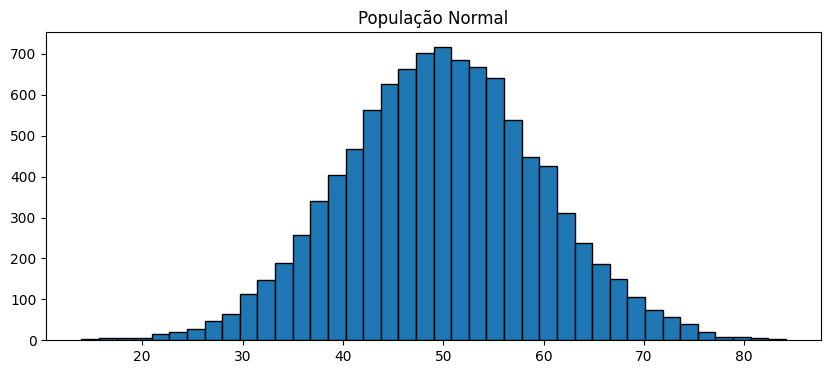

In [ ]:
plt.figure(figsize=(10,4))
plt.hist(pop_normal, bins=40, edgecolor="black")
plt.title("População Normal")
plt.show()

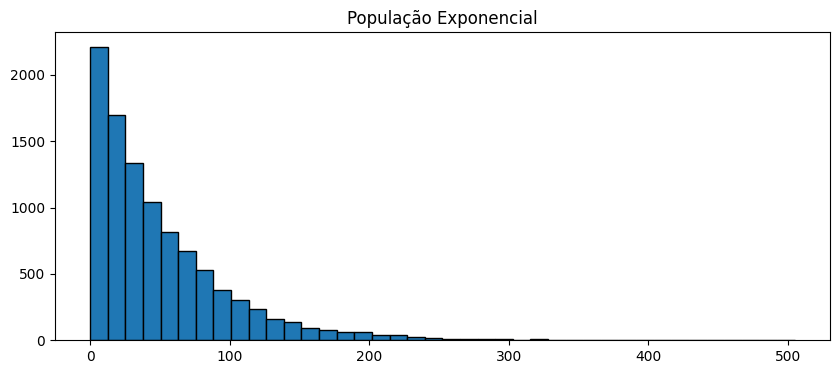

In [ ]:
plt.figure(figsize=(10,4))
plt.hist(pop_exponencial, bins=40, edgecolor="black")
plt.title("População Exponencial")
plt.show()

## Parte 6 — Simulação das médias amostrais

Nesta parte, vocês vão investigar o **Teorema do Limite Central (TLC)** por meio de simulações.

**`Para cada população`**, vocês devem trabalhar com:

```python
n_amostras = 1000
tamanhos_n = [16, 25, 36, 100, 400]
```

**`Para cada valor de n`**, vocês devem:

1. selecionar 1000 amostras de tamanho `n`;
2. calcular a média de cada amostra;
3. guardar as 1000 médias em uma lista;
4. construir histogramas das médias amostrais;
5. comparar o comportamento observado com o que é previsto pelo TLC.

Atenção: sempre que possível, usem `stat = "density"` nos histogramas das médias amostrais, pois isso facilita a comparação com a curva normal teórica.


In [ ]:
# Parâmetros gerais do trabalho
n_amostras = 1000  # número de amostras por simulação
tamanhos_n = [16, 25, 36, 100, 400]

### **Problema 1 — População normal**

Utilizando a **`pop_normal`** dada acima, faça o que se pede.


a) Calcule a média **mu** da população com uma casa decimal.


In [ ]:
mu = round(np.mean(pop_normal),1)
print(f"A média da população normal é {mu}.")

A média da população normal é 49.9.


b) Calcule o desvio padrão **sigma** da população com uma casa decimal.


In [ ]:
sigma = round(np.std(pop_normal),1)
print(f"O desvio padrão da população normal é {sigma}.")

O desvio padrão da população normal é 9.9.


c) Para cada valor de `n` na lista `tamanhos_n`, selecione **1000 amostras** da `população normal`. Calcule a média de cada amostra e guarde os resultados.

Sugestão de organização: crie um dicionário em que cada chave seja o valor de `n` e cada valor seja a lista com as 1000 médias amostrais.

Exemplo de estrutura esperada:

```python
medias_normal = {}
medias_normal[16] = [...]
medias_normal[25] = [...]
...
```


In [ ]:
medias_normal = {}

for n in tamanhos_n:
  medias = []
  for i in range(1000):
    amostra = choice(pop_normal, size = n, replace = False)
    media = amostra.mean()
    medias.append(media)
  medias_normal[n] = medias

medias_normal

{16: [np.float64(53.78673516433165),
  np.float64(52.977195960798085),
  np.float64(50.49266126562795),
  np.float64(49.54297437531714),
  np.float64(45.84446916823144),
  np.float64(46.730716195721826),
  np.float64(45.86878518966759),
  np.float64(51.90305969878495),
  np.float64(48.95180947310966),
  np.float64(47.026350139074104),
  np.float64(46.4363497187583),
  np.float64(47.02596392029129),
  np.float64(52.739787807319615),
  np.float64(49.161477514457374),
  np.float64(50.17632627278553),
  np.float64(48.06347083344032),
  np.float64(54.1870421646493),
  np.float64(49.66016381803381),
  np.float64(48.6473724344181),
  np.float64(51.829802672772175),
  np.float64(49.4453640012925),
  np.float64(50.84660186373224),
  np.float64(47.27382389300011),
  np.float64(49.590390737941604),
  np.float64(44.776640310250016),
  np.float64(48.32181019846714),
  np.float64(52.47229516719425),
  np.float64(46.14287120743248),
  np.float64(50.01547611709872),
  np.float64(46.697634020791966),
 

c-1) Faça os histogramas das médias amostrais **lado a lado**, um para cada valor de `n`.

Observe visualmente:

- a forma da distribuição das médias;
- a concentração das médias em torno da média populacional;
- a redução da dispersão quando `n` aumenta.


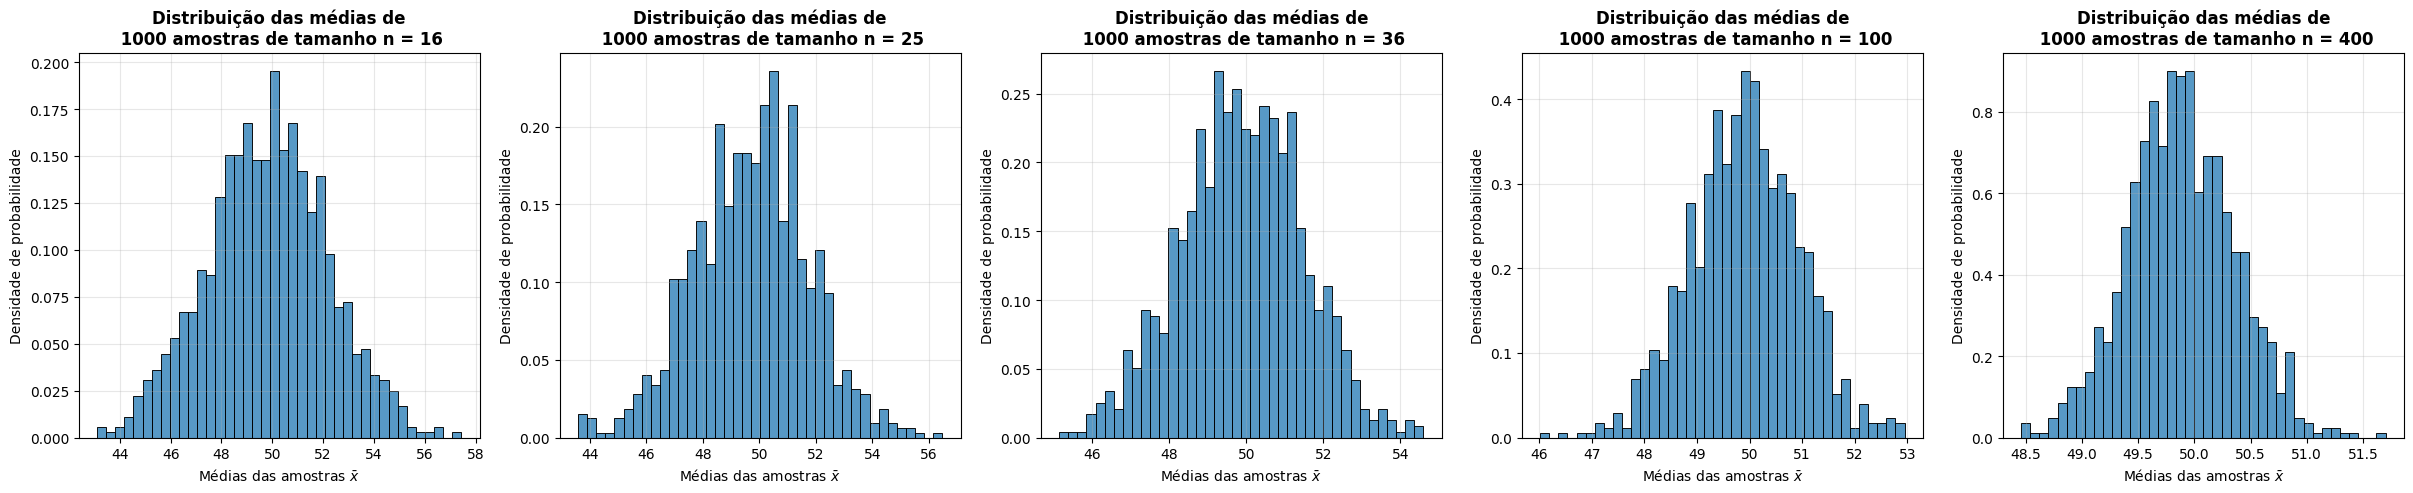

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(30, 5))

sns.histplot(medias_normal[16], bins= 40, stat = "density", ax = axes[0])
axes[0].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 16", fontweight="bold")
axes[0].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[0].set_ylabel("Densidade de probabilidade")
axes[0].grid(alpha=0.3)

sns.histplot(medias_normal[25], bins= 40, stat = "density", ax = axes[1])
axes[1].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 25", fontweight="bold")
axes[1].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[1].set_ylabel("Densidade de probabilidade")
axes[1].grid(alpha=0.3)

sns.histplot(medias_normal[36], bins= 40, stat = "density", ax = axes[2])
axes[2].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 36", fontweight="bold")
axes[2].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[2].set_ylabel("Densidade de probabilidade")
axes[2].grid(alpha=0.3)

sns.histplot(medias_normal[100], bins= 40, stat = "density", ax = axes[3])
axes[3].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 100", fontweight="bold")
axes[3].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[3].set_ylabel("Densidade de probabilidade")
axes[3].grid(alpha=0.3)

sns.histplot(medias_normal[400], bins= 40, stat = "density", ax = axes[4])
axes[4].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 400", fontweight="bold")
axes[4].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[4].set_ylabel("Densidade de probabilidade")
axes[4].grid(alpha=0.3)

plt.show()

c-2) Em cada histograma, sobreponha a **curva normal teórica** prevista pelo TLC.

Para isso, use:

- média teórica: `mu`;
- desvio padrão teórico das médias: `sigma / sqrt(n)`.

A curva normal teórica deve ajudar vocês a comparar a distribuição simulada das médias com a aproximação prevista pelo Teorema do Limite Central.


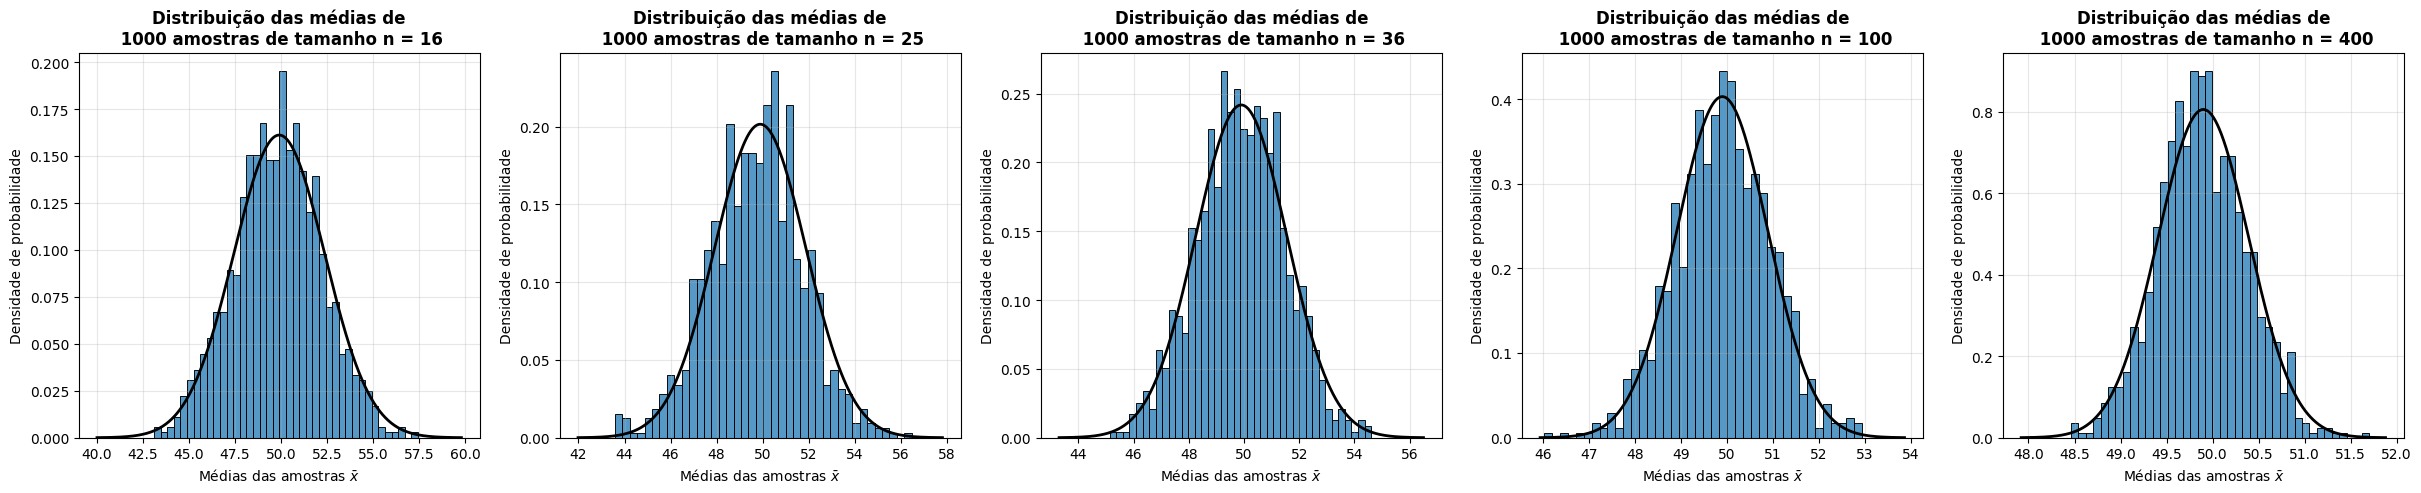

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(30, 5))

EPM_16 = sigma/np.sqrt(16)

X_16 = np.linspace(mu - 4 * EPM_16, mu + 4 * EPM_16, 1000)
y_16 = norm.pdf(X_16, mu, EPM_16)

sns.histplot(medias_normal[16], bins= 40, stat = "density", ax = axes[0])
axes[0].plot(X_16, y_16, linewidth=2, color = "black", label="Curva de Densidade de Probabilidade")
axes[0].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 16", fontweight="bold")
axes[0].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[0].set_ylabel("Densidade de probabilidade")
axes[0].grid(alpha=0.3)

EPM_25 = sigma/np.sqrt(25)

X_25 = np.linspace(mu - 4 * EPM_25, mu + 4 * EPM_25, 1000)
y_25 = norm.pdf(X_25, mu, EPM_25)

sns.histplot(medias_normal[25], bins= 40, stat = "density", ax = axes[1])
axes[1].plot(X_25, y_25, linewidth=2, color = "black", label="Curva de Densidade de Probabilidade")
axes[1].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 25", fontweight="bold")
axes[1].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[1].set_ylabel("Densidade de probabilidade")
axes[1].grid(alpha=0.3)

EPM_36 = sigma/np.sqrt(36)

X_36 = np.linspace(mu - 4 * EPM_36, mu + 4 * EPM_36, 1000)
y_36 = norm.pdf(X_36, mu, EPM_36)

sns.histplot(medias_normal[36], bins= 40, stat = "density", ax = axes[2])
axes[2].plot(X_36, y_36, linewidth=2, color = "black", label="Curva de Densidade de Probabilidade")
axes[2].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 36", fontweight="bold")
axes[2].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[2].set_ylabel("Densidade de probabilidade")
axes[2].grid(alpha=0.3)

EPM_100 = sigma/np.sqrt(100)

X_100 = np.linspace(mu - 4 * EPM_100, mu + 4 * EPM_100, 1000)
y_100 = norm.pdf(X_100, mu, EPM_100)

sns.histplot(medias_normal[100], bins= 40, stat = "density", ax = axes[3])
axes[3].plot(X_100, y_100, linewidth=2, color = "black", label="Curva de Densidade de Probabilidade")
axes[3].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 100", fontweight="bold")
axes[3].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[3].set_ylabel("Densidade de probabilidade")
axes[3].grid(alpha=0.3)

EPM_400 = sigma/np.sqrt(400)

X_400 = np.linspace(mu - 4 * EPM_400, mu + 4 * EPM_400, 1000)
y_400 = norm.pdf(X_400, mu, EPM_400)

sns.histplot(medias_normal[400], bins= 40, stat = "density", ax = axes[4])
axes[4].plot(X_400, y_400, linewidth=2, color = "black", label="Curva de Densidade de Probabilidade")
axes[4].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 400", fontweight="bold")
axes[4].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[4].set_ylabel("Densidade de probabilidade")
axes[4].grid(alpha=0.3)

plt.show()

c-3) A distribuição das médias amostrais parece normal para todos os valores de `n`?

Responda com base nos histogramas e na comparação com a curva normal teórica. Comente especialmente o que acontece quando `n` aumenta.


In [ ]:
print("""Sim, ela parece normal, pois como pode ser observado nos gráficos na questão c-2, todas as distribuições acompanham aproximadamente a curva normal teórica.

Conforme o n aumenta, a diferença entre elas é de que o erro padrão das médias diminui.""")

Sim, ela parece normal, pois como pode ser observado nos gráficos na questão c-2, todas as distribuições acompanham aproximadamente a curva normal teórica.

Conforme o n aumenta, a diferença entre elas é de que o erro padrão das médias diminui.


c-4) Calcule a **média das médias amostrais** para cada valor de `n`.

Depois, compare esses valores com a média populacional `mu`.

Monte uma tabela com as colunas:

| n | média das médias | média populacional |
|---|---:|---:|


In [ ]:
medias_das_medias = []

for n in tamanhos_n:
  media_medias = round(np.mean(medias_normal[n]),1)
  medias_das_medias.append(media_medias)
  print(f"Para n = {n}, a média das médias amostrais é {media_medias}.\n")

print(f"Comparando com a média populacional mu ({mu}), observamos que a média das médias das amostras é igual à média populacional.")

tabela_medias = pd.DataFrame(tamanhos_n, columns=['n'])
tabela_medias['Média das Médias'] = medias_das_medias
tabela_medias['Média Populacional'] = mu
display(tabela_medias)

Para n = 16, a média das médias amostrais é 49.8.

Para n = 25, a média das médias amostrais é 49.7.

Para n = 36, a média das médias amostrais é 49.9.

Para n = 100, a média das médias amostrais é 49.9.

Para n = 400, a média das médias amostrais é 49.9.

Comparando com a média populacional mu (49.9), observamos que a média das médias das amostras é igual à média populacional.


,n,Média das Médias,Média Populacional
0,16,49.8,49.9
1,25,49.7,49.9
2,36,49.9,49.9
3,100,49.9,49.9
4,400,49.9,49.9


c-5) Calcule o **EPM observado** e o **EPM teórico** para cada valor de `n`.

- EPM observado: desvio padrão das 1000 médias amostrais;
- EPM teórico: `sigma / sqrt(n)`.

Monte uma tabela com as colunas:

| n | EPM observado | EPM teórico |
|---|---:|---:|

Essa comparação permite verificar se o comportamento observado nas simulações é consistente com o que o TLC prevê.


In [ ]:
epmteorico = []
epmobservado = []

for n in tamanhos_n:
  epm_t = sigma / np.sqrt(n)
  epmteorico.append(epm_t)
  epm_o = np.std(medias_normal[n])
  epmobservado.append(epm_o)


tabela_epm = pd.DataFrame(tamanhos_n, columns=['n'])
tabela_epm['EPM Observado'] = epmobservado
tabela_epm['EPM Teórico'] = epmteorico
display(tabela_epm)

,n,EPM Observado,EPM Teórico
0,16,2.352932,2.475
1,25,2.019567,1.980
2,36,1.586021,1.650
3,100,1.031767,0.990
4,400,0.477379,0.495


c-6) Faça um gráfico comparando o **EPM observado** e o **EPM teórico** em função de `n`.

No eixo x, coloque os valores de `n`. No eixo y, coloque o EPM.

Esse gráfico deve mostrar a queda da variabilidade das médias amostrais quando o tamanho da amostra aumenta.


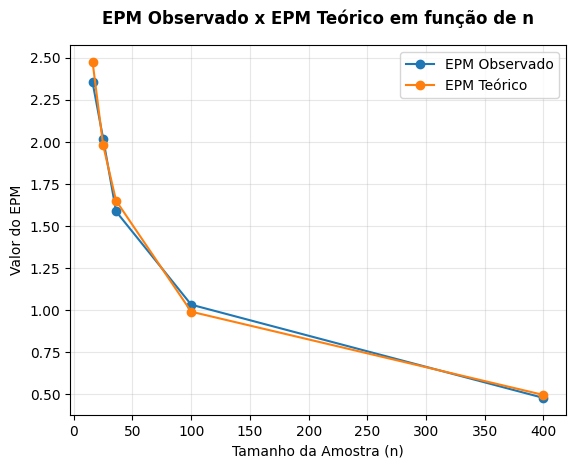

In [ ]:
tabela_epm.plot(x='n',y=['EPM Observado','EPM Teórico'], linestyle='-', marker="o")
plt.title("EPM Observado x EPM Teórico em função de n", pad=15, fontweight="bold")
plt.xlabel("Tamanho da Amostra (n)")
plt.ylabel("Valor do EPM")
plt.grid(alpha=0.3)
plt.show()

c-7) O desvio padrão das médias amostrais se aproxima do valor previsto pelo TLC?

Explique usando a tabela e o gráfico do EPM observado versus EPM teórico.


In [ ]:
print(f"""Sim, os valores ficam muito próximos. Como podemos ver pela tabela, temos os seguintes valores de EPM Observado x EPM Teórico para cada n:

n = 16 -> {tabela_epm['EPM Observado'][0].round(2)} x {tabela_epm['EPM Teórico'][0].round(2)}, com uma diferença de {round(abs(tabela_epm['EPM Observado'][0]-tabela_epm['EPM Teórico'][0]),2)} entre eles.
n = 25 -> {tabela_epm['EPM Observado'][1].round(2)} x {tabela_epm['EPM Teórico'][1].round(2)}, com uma diferença de {round(abs(tabela_epm['EPM Observado'][1]-tabela_epm['EPM Teórico'][1]),2)} entre eles.
n = 36 -> {tabela_epm['EPM Observado'][2].round(2)} x {tabela_epm['EPM Teórico'][2].round(2)}, com uma diferença de {round(abs(tabela_epm['EPM Observado'][2]-tabela_epm['EPM Teórico'][2]),2)} entre eles.
n = 100 -> {tabela_epm['EPM Observado'][3].round(2)} x {tabela_epm['EPM Teórico'][3].round(2)}, com uma diferença de {round(abs(tabela_epm['EPM Observado'][3]-tabela_epm['EPM Teórico'][3]),2)} entre eles.
n = 400 -> {tabela_epm['EPM Observado'][4].round(2)} x {tabela_epm['EPM Teórico'][4].round(2)}, com uma diferença de {round(abs(tabela_epm['EPM Observado'][4]-tabela_epm['EPM Teórico'][4]),2)} entre eles.

No gráfico, essa diferença mínima se observa pela quase sobreposição dos pontos que representam o EPM Observado versus o Teórico.""")

Sim, os valores ficam muito próximos. Como podemos ver pela tabela, temos os seguintes valores de EPM Observado x EPM Teórico para cada n:

n = 16 -> 2.35 x 2.48, com uma diferença de 0.12 entre eles.
n = 25 -> 2.02 x 1.98, com uma diferença de 0.04 entre eles.
n = 36 -> 1.59 x 1.65, com uma diferença de 0.06 entre eles.
n = 100 -> 1.03 x 0.99, com uma diferença de 0.04 entre eles.
n = 400 -> 0.48 x 0.5, com uma diferença de 0.02 entre eles.

No gráfico, essa diferença mínima se observa pela quase sobreposição dos pontos que representam o EPM Observado versus o Teórico.


### **Problema 2 — População exponencial**

Utilizando a **`pop_exponencial`** dada acima, faça o que se pede.


a) Calcule a média **mu** da população com uma casa decimal.


In [ ]:
mu = round(np.mean(pop_exponencial),1)
print(f"A média da população exponencial é {mu}.")

A média da população exponencial é 50.5.


b) Calcule o desvio padrão **sigma** da população com uma casa decimal.


In [ ]:
sigma = round(np.std(pop_exponencial),1)
print(f"O desvio padrão da população exponencial é {sigma}.")

O desvio padrão da população exponencial é 50.3.


c) Para cada valor de `n` na lista `tamanhos_n`, selecione **1000 amostras** da `população exponencial`. Calcule a média de cada amostra e guarde os resultados.

Sugestão de organização: crie um dicionário em que cada chave seja o valor de `n` e cada valor seja a lista com as 1000 médias amostrais.

Exemplo de estrutura esperada:

```python
medias_exponencial = {}
medias_exponencial[16] = [...]
medias_exponencial[25] = [...]
...
```


In [ ]:
medias_exponencial = {}

for n in tamanhos_n:
  medias_exp = []
  for i in range(1000):
    amostra = choice(pop_exponencial, size = n, replace = False)
    media_exp = amostra.mean()
    medias_exp.append(media_exp)
  medias_exponencial[n] = medias_exp

medias_exponencial

{16: [np.float64(40.24915908150676),
  np.float64(52.08292278705111),
  np.float64(51.90516811548499),
  np.float64(60.77101579236245),
  np.float64(29.0261347649578),
  np.float64(52.48612277239496),
  np.float64(49.58104054848711),
  np.float64(51.6479204238032),
  np.float64(68.11925066504108),
  np.float64(64.02368695922276),
  np.float64(56.556305478339254),
  np.float64(44.335083680359205),
  np.float64(45.084342111461275),
  np.float64(59.125283116604976),
  np.float64(38.15685259160327),
  np.float64(65.81042603084343),
  np.float64(58.67781399483967),
  np.float64(57.28239052014078),
  np.float64(51.67395158278948),
  np.float64(45.221244682744455),
  np.float64(63.45595199731125),
  np.float64(64.763437963283),
  np.float64(55.17922847684894),
  np.float64(53.74338324346128),
  np.float64(55.36671074869592),
  np.float64(60.646287128898535),
  np.float64(36.266523680686454),
  np.float64(52.8302948520471),
  np.float64(49.082176485652646),
  np.float64(56.28614354123751),
  n

c-1) Faça os histogramas das médias amostrais **lado a lado**, um para cada valor de `n`.

Observe visualmente:

- a forma da distribuição das médias;
- a concentração das médias em torno da média populacional;
- a redução da dispersão quando `n` aumenta.


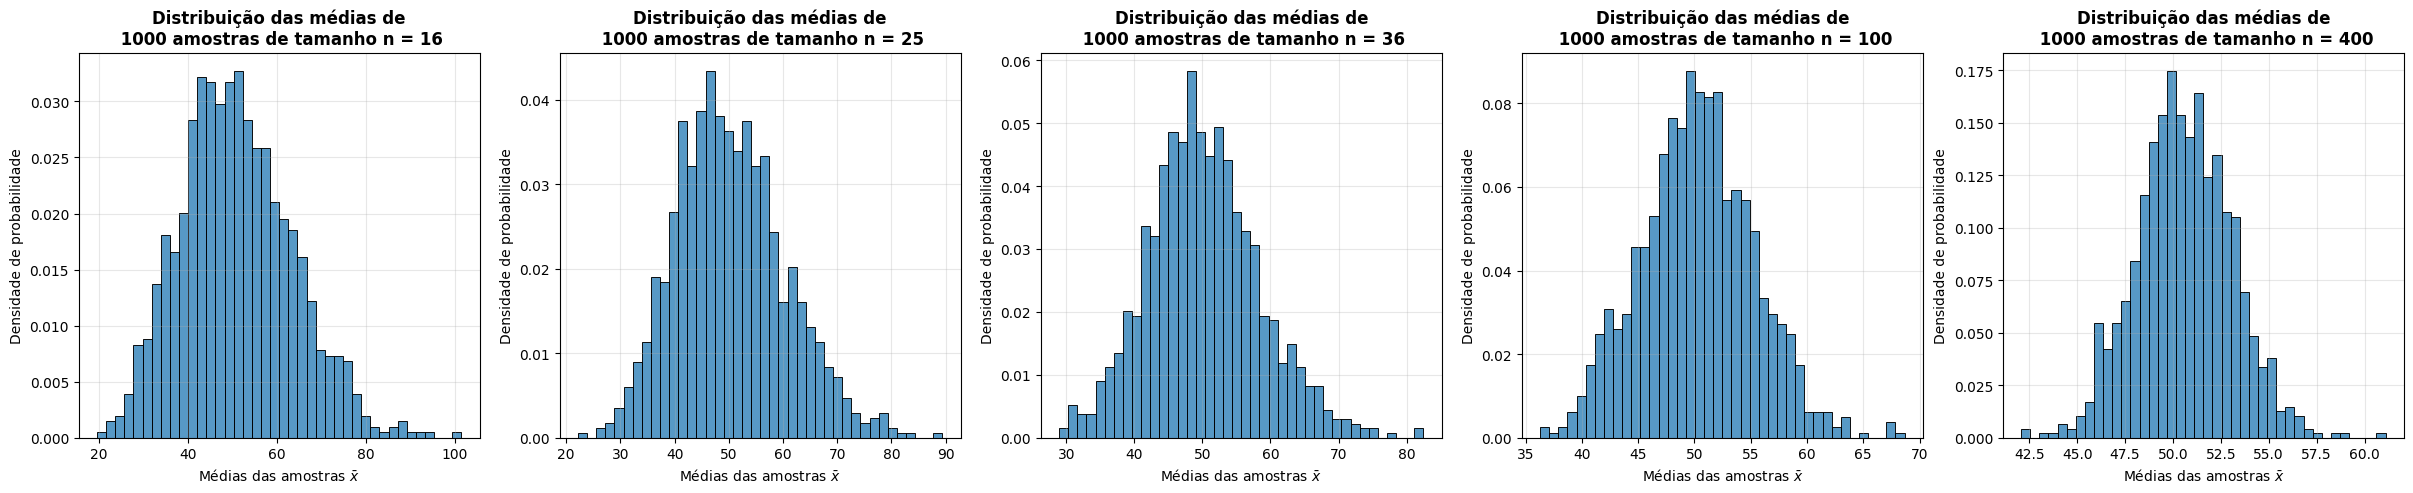

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(30, 5))

sns.histplot(medias_exponencial[16], bins= 40, stat = "density", ax = axes[0])
axes[0].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 16", fontweight="bold")
axes[0].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[0].set_ylabel("Densidade de probabilidade")
axes[0].grid(alpha=0.3)

sns.histplot(medias_exponencial[25], bins= 40, stat = "density", ax = axes[1])
axes[1].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 25", fontweight="bold")
axes[1].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[1].set_ylabel("Densidade de probabilidade")
axes[1].grid(alpha=0.3)

sns.histplot(medias_exponencial[36], bins= 40, stat = "density", ax = axes[2])
axes[2].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 36", fontweight="bold")
axes[2].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[2].set_ylabel("Densidade de probabilidade")
axes[2].grid(alpha=0.3)

sns.histplot(medias_exponencial[100], bins= 40, stat = "density", ax = axes[3])
axes[3].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 100", fontweight="bold")
axes[3].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[3].set_ylabel("Densidade de probabilidade")
axes[3].grid(alpha=0.3)

sns.histplot(medias_exponencial[400], bins= 40, stat = "density", ax = axes[4])
axes[4].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 400", fontweight="bold")
axes[4].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[4].set_ylabel("Densidade de probabilidade")
axes[4].grid(alpha=0.3)

plt.show()

c-2) Em cada histograma, sobreponha a **curva normal teórica** prevista pelo TLC.

Para isso, use:

- média teórica: `mu`;
- desvio padrão teórico das médias: `sigma / sqrt(n)`.

A curva normal teórica deve ajudar vocês a comparar a distribuição simulada das médias com a aproximação prevista pelo Teorema do Limite Central.


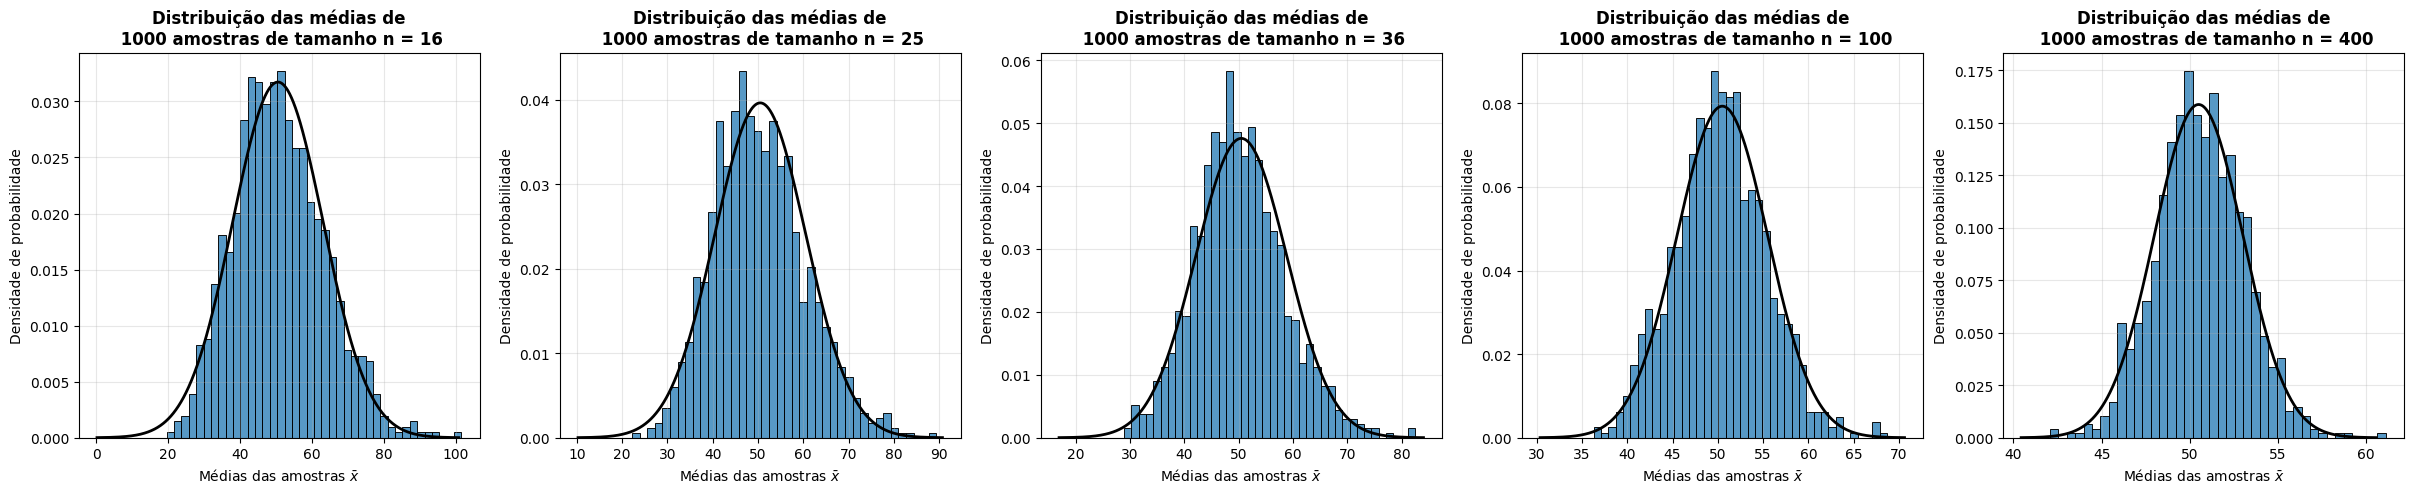

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(30, 5))

EPM_exp_16 = sigma/np.sqrt(16)

X_exp_16 = np.linspace(mu - 4 * EPM_exp_16, mu + 4 * EPM_exp_16, 1000)
y_exp_16 = norm.pdf(X_exp_16, mu, EPM_exp_16)

sns.histplot(medias_exponencial[16], bins= 40, stat = "density", ax = axes[0])
axes[0].plot(X_exp_16, y_exp_16, linewidth=2, color = "black", label="Curva de Densidade de Probabilidade")
axes[0].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 16", fontweight="bold")
axes[0].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[0].set_ylabel("Densidade de probabilidade")
axes[0].grid(alpha=0.3)

EPM_exp_25 = sigma/np.sqrt(25)

X_exp_25 = np.linspace(mu - 4 * EPM_exp_25, mu + 4 * EPM_exp_25, 1000)
y_exp_25 = norm.pdf(X_exp_25, mu, EPM_exp_25)

sns.histplot(medias_exponencial[25], bins= 40, stat = "density", ax = axes[1])
axes[1].plot(X_exp_25, y_exp_25, linewidth=2, color = "black", label="Curva de Densidade de Probabilidade")
axes[1].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 25", fontweight="bold")
axes[1].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[1].set_ylabel("Densidade de probabilidade")
axes[1].grid(alpha=0.3)

EPM_exp_36 = sigma/np.sqrt(36)

X_exp_36 = np.linspace(mu - 4 * EPM_exp_36, mu + 4 * EPM_exp_36, 1000)
y_exp_36 = norm.pdf(X_exp_36, mu, EPM_exp_36)

sns.histplot(medias_exponencial[36], bins= 40, stat = "density", ax = axes[2])
axes[2].plot(X_exp_36, y_exp_36, linewidth=2, color = "black", label="Curva de Densidade de Probabilidade")
axes[2].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 36", fontweight="bold")
axes[2].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[2].set_ylabel("Densidade de probabilidade")
axes[2].grid(alpha=0.3)

EPM_exp_100 = sigma/np.sqrt(100)

X_exp_100 = np.linspace(mu - 4 * EPM_exp_100, mu + 4 * EPM_exp_100, 1000)
y_exp_100 = norm.pdf(X_exp_100, mu, EPM_exp_100)

sns.histplot(medias_exponencial[100], bins= 40, stat = "density", ax = axes[3])
axes[3].plot(X_exp_100, y_exp_100, linewidth=2, color = "black", label="Curva de Densidade de Probabilidade")
axes[3].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 100", fontweight="bold")
axes[3].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[3].set_ylabel("Densidade de probabilidade")
axes[3].grid(alpha=0.3)

EPM_exp_400 = sigma/np.sqrt(400)

X_exp_400 = np.linspace(mu - 4 * EPM_exp_400, mu + 4 * EPM_exp_400, 1000)
y_exp_400 = norm.pdf(X_exp_400, mu, EPM_exp_400)

sns.histplot(medias_exponencial[400], bins= 40, stat = "density", ax = axes[4])
axes[4].plot(X_exp_400, y_exp_400, linewidth=2, color = "black", label="Curva de Densidade de Probabilidade")
axes[4].set_title("Distribuição das médias de\n 1000 amostras de tamanho n = 400", fontweight="bold")
axes[4].set_xlabel(r"Médias das amostras $\bar{x}$")
axes[4].set_ylabel("Densidade de probabilidade")
axes[4].grid(alpha=0.3)

plt.show()

c-3) A distribuição das médias amostrais parece normal para todos os valores de `n`?

Responda com base nos histogramas e na comparação com a curva normal teórica. Comente especialmente o que acontece quando `n` aumenta.


In [ ]:
print("""Não, nem todas parecem normais. Para n < 30, principalmente n = 16, a distribuição das médias ainda se assemelha mais a uma distribuição exponencial,
com lados assimétricos/cauda para um dos lados. Isto é particularmente visível ao se sobrepor a curva normal teórica.

Somente conforme o n aumenta, como em n = 100 e n = 400, é possível perceber a distribuição se aproximando mais do formato da curva teórica. Com o aumento do tamanho da amostra, também diminui
o erro padrão da média.""")

Não, nem todas parecem normais. Para n < 30, principalmente n = 16, a distribuição das médias ainda se assemelha mais a uma distribuição exponencial,
com lados assimétricos/cauda para um dos lados. Isto é particularmente visível ao se sobrepor a curva normal teórica.

Somente conforme o n aumenta, como em n = 100 e n = 400, é possível perceber a distribuição se aproximando mais do formato da curva teórica. Com o aumento do tamanho da amostra, também diminui
o erro padrão da média.


c-4) Calcule a **média das médias amostrais** para cada valor de `n`.

Depois, compare esses valores com a média populacional `mu`.

Monte uma tabela com as colunas:

| n | média das médias | média populacional |
|---|---:|---:|


In [ ]:
medias_das_medias_exp = []

for n in tamanhos_n:
  media_medias_exp = round(np.mean(medias_exponencial[n]),1)
  medias_das_medias_exp.append(media_medias_exp)
  print(f"Para n = {n}, a média das médias amostrais é {media_medias_exp}.\n")

print(f"""Comparando com a média populacional mu ({mu}), observamos que a média das médias das amostras é praticamente igual à média da população exponencial.\n""")

tabela_medias_exp = pd.DataFrame(tamanhos_n, columns=['n'])
tabela_medias_exp['Média das Médias'] = medias_das_medias_exp
tabela_medias_exp['Média Populacional'] = mu
display(tabela_medias_exp)

Para n = 16, a média das médias amostrais é 51.0.

Para n = 25, a média das médias amostrais é 50.4.

Para n = 36, a média das médias amostrais é 50.2.

Para n = 100, a média das médias amostrais é 50.3.

Para n = 400, a média das médias amostrais é 50.6.

Comparando com a média populacional mu (50.5), observamos que a média das médias das amostras é praticamente igual à média da população exponencial.



,n,Média das Médias,Média Populacional
0,16,51.0,50.5
1,25,50.4,50.5
2,36,50.2,50.5
3,100,50.3,50.5
4,400,50.6,50.5


c-5) Calcule o **EPM observado** e o **EPM teórico** para cada valor de `n`.

- EPM observado: desvio padrão das 1000 médias amostrais;
- EPM teórico: `sigma / sqrt(n)`.

Monte uma tabela com as colunas:

| n | EPM observado | EPM teórico |
|---|---:|---:|

Essa comparação permite verificar se o comportamento observado nas simulações é consistente com o que o TLC prevê.


In [ ]:
epmteorico_exp = []
epmobservado_exp = []

for n in tamanhos_n:
  epm_t_exp = sigma / np.sqrt(n)
  epmteorico_exp.append(epm_t_exp)
  epm_o_exp = np.std(medias_exponencial[n])
  epmobservado_exp.append(epm_o_exp)


tabela_epm_exp = pd.DataFrame(tamanhos_n, columns=['n'])
tabela_epm_exp['EPM Observado'] = epmobservado_exp
tabela_epm_exp['EPM Teórico'] = epmteorico_exp
display(tabela_epm_exp)

,n,EPM Observado,EPM Teórico
0,16,12.528194,12.575000
1,25,10.131640,10.060000
2,36,8.201985,8.383333
3,100,4.991520,5.030000
4,400,2.472379,2.515000


c-6) Faça um gráfico comparando o **EPM observado** e o **EPM teórico** em função de `n`.

No eixo x, coloque os valores de `n`. No eixo y, coloque o EPM.

Esse gráfico deve mostrar a queda da variabilidade das médias amostrais quando o tamanho da amostra aumenta.


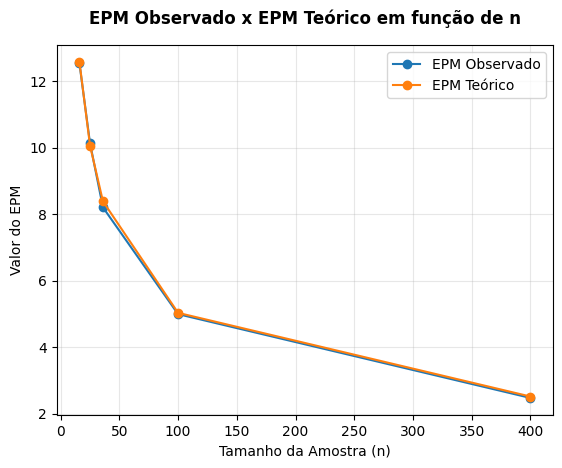

In [ ]:
tabela_epm_exp.plot(x='n',y=['EPM Observado','EPM Teórico'], linestyle='-', marker="o")
plt.title("EPM Observado x EPM Teórico em função de n", pad=15, fontweight="bold")
plt.xlabel("Tamanho da Amostra (n)")
plt.ylabel("Valor do EPM")
plt.grid(alpha=0.3)
plt.show()

c-7) O desvio padrão das médias amostrais se aproxima do valor previsto pelo TLC?

Explique usando a tabela e o gráfico do EPM observado versus EPM teórico.


In [ ]:
print(f"""Sim, os valores ficam muito próximos. Como podemos ver pela tabela, temos os seguintes valores de EPM Observado x EPM Teórico para cada n:

n = 16 -> {tabela_epm_exp['EPM Observado'][0].round(2)} x {tabela_epm_exp['EPM Teórico'][0].round(2)}, com uma diferença de {round(abs(tabela_epm_exp['EPM Observado'][0]-tabela_epm_exp['EPM Teórico'][0]),2)} entre eles.
n = 25 -> {tabela_epm_exp['EPM Observado'][1].round(2)} x {tabela_epm_exp['EPM Teórico'][1].round(2)}, com uma diferença de {round(abs(tabela_epm_exp['EPM Observado'][1]-tabela_epm_exp['EPM Teórico'][1]),2)} entre eles.
n = 36 -> {tabela_epm_exp['EPM Observado'][2].round(2)} x {tabela_epm_exp['EPM Teórico'][2].round(2)}, com uma diferença de {round(abs(tabela_epm_exp['EPM Observado'][2]-tabela_epm_exp['EPM Teórico'][2]),2)} entre eles.
n = 100 -> {tabela_epm_exp['EPM Observado'][3].round(2)} x {tabela_epm_exp['EPM Teórico'][3].round(2)}, com uma diferença de {round(abs(tabela_epm_exp['EPM Observado'][3]-tabela_epm_exp['EPM Teórico'][3]),2)} entre eles.
n = 400 -> {tabela_epm_exp['EPM Observado'][4].round(2)} x {tabela_epm_exp['EPM Teórico'][4].round(2)}, com uma diferença de {round(abs(tabela_epm_exp['EPM Observado'][4]-tabela_epm_exp['EPM Teórico'][4]),2)} entre eles.

No gráfico, essa diferença mínima se observa pela quase sobreposição dos pontos que representam o EPM Observado versus o Teórico.""")

Sim, os valores ficam muito próximos. Como podemos ver pela tabela, temos os seguintes valores de EPM Observado x EPM Teórico para cada n:

n = 16 -> 12.53 x 12.58, com uma diferença de 0.05 entre eles.
n = 25 -> 10.13 x 10.06, com uma diferença de 0.07 entre eles.
n = 36 -> 8.2 x 8.38, com uma diferença de 0.18 entre eles.
n = 100 -> 4.99 x 5.03, com uma diferença de 0.04 entre eles.
n = 400 -> 2.47 x 2.51, com uma diferença de 0.04 entre eles.

No gráfico, essa diferença mínima se observa pela quase sobreposição dos pontos que representam o EPM Observado versus o Teórico.


### **Problema 3 — Conclusão geral**

Agora responda às perguntas finais, usando os resultados obtidos nos quatro problemas anteriores.


a) A distribuição das médias amostrais é sempre normal ou depende? Justifique usando os exemplos das populações normal e exponencial.


In [ ]:
print("""Depende do tamanho da amostra. Nos exemplos das populações normais, os histogramas sempre se mantém com o formato de uma distribuição normal, devido à base de dados ser simétrica, ou seja,
ela sempre formará uma distribuição normal.

Mas nos exemplos da população exponencial, quando se observa os histogramas com um tamanho de amostra (n) menor, as médias amostrais são distorcidas. Somente com o aumento do n vai sendo construído o
formato de uma distribuição normal, principalmente para quando n ≥ 30. """)

Depende do tamanho da amostra. Nos exemplos das populações normais, os histogramas sempre se mantém com o formato de uma distribuição normal, devido à base de dados ser simétrica, ou seja, 
ela sempre formará uma distribuição normal. 

Mas nos exemplos da população exponencial, quando se observa os histogramas com um tamanho de amostra (n) menor, as médias amostrais são distorcidas. Somente com o aumento do n vai sendo construído o 
formato de uma distribuição normal, principalmente para quando n ≥ 30. 


b) O que acontece com a distribuição das médias amostrais quando `n` aumenta? Comente a forma, o centro e a dispersão da distribuição.


In [ ]:
print("""Conforme n aumenta, seja para a população normal ou exponencial, a forma fica cada vez mais parecida com uma curva normal, criando um formato simétrico no meio, como um sino,
visto nos histogramas apresentados.

O centro permanece o mesmo, ou seja, a distribuição continua centrada na média da população, já que a esperança (média) das médias amostrais é igual a média de toda a população.

Já a dispersão diminui devido ao Erro Padrão da Média (EPM) ir diminuindo conforme o aumento do n, indicando que as médias amostrais ficam mais concentradas, ou seja, variam menos entre si.""")

Conforme n aumenta, seja para a população normal ou exponencial, a forma fica cada vez mais parecida com uma curva normal, criando um formato simétrico no meio, como um sino, 
visto nos histogramas apresentados. 

O centro permanece o mesmo, ou seja, a distribuição continua centrada na média da população, já que a esperança (média) das médias amostrais é igual a média de toda a população.  

Já a dispersão diminui devido ao Erro Padrão da Média (EPM) ir diminuindo conforme o aumento do n, indicando que as médias amostrais ficam mais concentradas, ou seja, variam menos entre si.


c) O que aconteceu com o EPM quando `n` aumentou? Relacione sua resposta com a fórmula `sigma / sqrt(n)`.


In [ ]:
print("""A cada vez que o n aumentava, o EPM diminuia consideravelmente. Pela fórmula descrita acima, o desvio padrão é dividido pela raiz do tamanho das amostras, ou seja, eles são
inversamentes proporcionais. Então, quanto maior for o n, maior será a divisão feita e, consequentemente, menor será o resultado obtido.

Pelo fato do n aumentar durante o processo dos histogramas (16 -> 25 -> 36 -> 100 -> 400), o divisor foi crescendo e, com isso, o resultado final (EPM) foi se tornando cada vez menor.
Com isso tudo, mostra-se que, quanto maior as amostras, menores serão as incertezas sobre a média real da população.""")

A cada vez que o n aumentava, o EPM diminuia consideravelmente. Pela fórmula descrita acima, o desvio padrão é dividido pela raiz do tamanho das amostras, ou seja, eles são 
inversamentes proporcionais. Então, quanto maior for o n, maior será a divisão feita e, consequentemente, menor será o resultado obtido. 

Pelo fato do n aumentar durante o processo dos histogramas (16 -> 25 -> 36 -> 100 -> 400), o divisor foi crescendo e, com isso, o resultado final (EPM) foi se tornando cada vez menor. 
Com isso tudo, mostra-se que, quanto maior as amostras, menores serão as incertezas sobre a média real da população.


d) Compare o comportamento do TLC nas populações normal e exponencial. Em qual delas a aproximação normal ficou mais evidente para valores pequenos de n? Explique.


In [ ]:
print("""Comparando o comportamento do TLC nas populações normal e exponencial, fica claro que a aproximação normal para valores pequenos de n ficou mais evidente para a população normal. Na
população normal, a distribuição normal já é evidente em tamanhos de amostras menores, pois a média que é retirada de dados que já são normais, consequentemente também será normal.

Mas, se analisarmos a população exponencial, nota-se que, com valores de n menores, os histogramas não apresentam uma curva normal diretamente, mas sim uma curva assimétrica, comportamento normal dos
dados de uma população exponencial, devido à vários valores com uma proximidade maior para a esquerda. Então, com valores menores de n, a população normal apresenta uma aproximação maior da normal.""")

Comparando o comportamento do TLC nas populações normal e exponencial, fica claro que a aproximação normal para valores pequenos de n ficou mais evidente para a população normal. Na 
população normal, a distribuição normal já é evidente em tamanhos de amostras menores, pois a média que é retirada de dados que já são normais, consequentemente também será normal. 

Mas, se analisarmos a população exponencial, nota-se que, com valores de n menores, os histogramas não apresentam uma curva normal diretamente, mas sim uma curva assimétrica, comportamento normal dos 
dados de uma população exponencial, devido à vários valores com uma proximidade maior para a esquerda. Então, com valores menores de n, a população normal apresenta uma aproximação maior da normal.


e) Explique, com suas palavras, por que o Teorema do Limite Central é importante para a Estatística e para a Ciência de Dados.


In [ ]:
print("""O Teorema do Limite Central (TLC) é muito importante para a Estatística e para a Ciência de Dados. No mundo real, o conhecimento sobre dados de determinada população ou de qualquer análise
que você irá fazer nunca estarão da forma desejada, mas sim tortos ou desconexos. Então, o Teorema do Limite Central aparece como uma ajuda nesses problemas. O TLC traz como pensamento que, não importa
o qual estranho ou difícil está a sua população, se você obtiver um número suficientemente grande de amostras, no final, os dados irão se comportar como uma distribuição normal, com a média centralizada
ao meio. Outro ponto importante sempre será a limitação de acesso aos dados, pois um cientista de dados dificilmente terá todos os dados dentro de uma população. Então, o TLC mostra que, com um
determinado tamanho de amostras, pode-se calcular a média e prever qual a margem de erro naquela análise.

Com isso, nota-se a importância do Teorema do Limite Central para a área da Estatística e Ciência de Dados.""")

O Teorema do Limite Central (TLC) é muito importante para a Estatística e para a Ciência de Dados. No mundo real, o conhecimento sobre dados de determinada população ou de qualquer análise 
que você irá fazer nunca estarão da forma desejada, mas sim tortas ou desconexas. Então, o Teorema do Limite Central aparece como uma ajuda nesses problemas. O TLC traz como pensamento que, não importa 
o qual estranho ou difícil está a sua população, se você obtiver um número suficientemente grande de amostras, no final, os dados irão se comportar como uma distribuição normal, com a média centralizada 
ao meio. Outro ponto importante sempre será a limitação de acesso aos dados, pois um cientista de dados dificilmente terá todos os dados dentro de uma população. Então, o TLC mostra que, com um 
determinado tamanho de amostras, pode-se calcular a média e prever qual a margem de erro naquela análise.

Com isso, nota-se a importância do Teorema do Limite Central para a área da Estatística e Ciência de 

f) Dê um exemplo prático de uma situação real em que o TLC ajuda a justificar o uso de médias amostrais para fazer inferências sobre uma população.


In [ ]:
print("""Um exemplo de aplicação do TLC são as pesquisas eleitorais.

Imagine uma eleição em que 52% dos eleitores pretendem votar no candidato A. A distribuição do voto individual é binária (vota ou não vota no candidato), ou seja, nada parecida com uma normal.
Ainda assim, quando uma pesquisa coleta uma amostra de 1.000 eleitores, por exemplo, e calcula a proporção que apoia o candidato A, essa proporção se comporta como uma variável aproximadamente normal,
com média 52% e EPM = σ/√n.

É exatamente por isso que as pesquisas conseguem estimar resultados com margem de erro definida, como por exemplo, “52% + ou - 3 pontos percentuais”, mesmo sem entrevistar todos os eleitores.
O TLC é o que torna essa margem de erro válida.""")

Um exemplo de aplicação do TLC são as pesquisas eleitorais. 

Imagine uma eleição em que 52% dos eleitores pretendem votar no candidato A. A distribuição do voto individual é binária (vota ou não vota no candidato), ou seja, nada parecida com uma normal. 
Ainda assim, quando uma pesquisa coleta uma amostra de 1.000 eleitores, por exemplo, e calcula a proporção que apoia o candidato A, essa proporção se comporta como uma variável aproximadamente normal, 
com média 52% e EPM = σ/√n. 

É exatamente por isso que as pesquisas conseguem estimar resultados com margem de erro definida, como por exemplo, “52% + ou - 3 pontos percentuais”, mesmo sem entrevistar todos os eleitores. 
O TLC é o que torna essa margem de erro válida.


## Apêndice — Dicas de implementação

As dicas abaixo não resolvem o trabalho, mas mostram comandos úteis que podem ser adaptados pelos grupos.

- `random.choices(populacao, k=n)` seleciona uma amostra com reposição;
- `np.mean(lista)` calcula a média;
- `np.std(lista, ddof=1)` calcula o desvio padrão amostral;
- `plt.histplot(dados, stat = "density")` faz o histograma em escala de densidade;
- `norm.pdf(x, loc=media, scale=desvio)` calcula os valores da curva normal.

Para a curva normal teórica do TLC, use:

```python
media_teorica = mu
epm_teorico = sigma / np.sqrt(n)
```
